In [127]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

In [128]:
df=pd.read_excel("Car Sales.xlsx")

In [129]:
df.head()

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
0,C_CND_000001,2022-01-02,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown
1,C_CND_000002,2022-01-02,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora
2,C_CND_000003,2022-01-02,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville
3,C_CND_000004,2022-01-02,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco
4,C_CND_000005,2022-01-02,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville


In [130]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23906 entries, 0 to 23905
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Car_id         23906 non-null  object        
 1   Date           23906 non-null  datetime64[ns]
 2   Customer Name  23905 non-null  object        
 3   Gender         23906 non-null  object        
 4   Annual Income  23906 non-null  int64         
 5   Dealer_Name    23906 non-null  object        
 6   Company        23906 non-null  object        
 7   Model          23906 non-null  object        
 8   Engine         23906 non-null  object        
 9   Transmission   23906 non-null  object        
 10  Color          23906 non-null  object        
 11  Price ($)      23906 non-null  int64         
 12  Dealer_No      23906 non-null  object        
 13  Body Style     23906 non-null  object        
 14  Phone          23906 non-null  int64         
 15  Dealer_Region  2390

,Date,Annual Income,Price ($),Phone
count,23906,2.390600e+04,23906.000000,2.390600e+04
mean,2023-03-01 14:28:10.822387456,8.308403e+05,28090.247846,7.497741e+06
min,2022-01-02 00:00:00,1.008000e+04,1200.000000,6.000101e+06
25%,2022-09-20 00:00:00,3.860000e+05,18001.000000,6.746495e+06
50%,2023-03-13 00:00:00,7.350000e+05,23000.000000,7.496198e+06
75%,2023-09-08 00:00:00,1.175750e+06,34000.000000,8.248146e+06
max,2023-12-31 00:00:00,1.120000e+07,85800.000000,8.999579e+06
std,NaN,7.200064e+05,14788.687608,8.674920e+05


In [131]:
df.isnull()


,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23901,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
23902,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
23903,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
23904,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [132]:
df.isnull().sum()


Car_id           0
Date             0
Customer Name    1
Gender           0
Annual Income    0
Dealer_Name      0
Company          0
Model            0
Engine           0
Transmission     0
Color            0
Price ($)        0
Dealer_No        0
Body Style       0
Phone            0
Dealer_Region    0
dtype: int64

In [133]:
df.dropna(inplace=True)
df.isnull().sum()

Car_id           0
Date             0
Customer Name    0
Gender           0
Annual Income    0
Dealer_Name      0
Company          0
Model            0
Engine           0
Transmission     0
Color            0
Price ($)        0
Dealer_No        0
Body Style       0
Phone            0
Dealer_Region    0
dtype: int64

In [134]:
df[['Annual Income', 'Price ($)']].skew()


Annual Income    1.739781
Price ($)        1.466487
dtype: float64

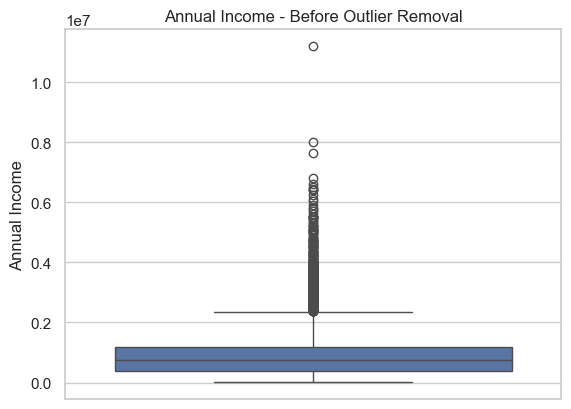

In [135]:
sns.boxplot(y=df['Annual Income'])
plt.title("Annual Income - Before Outlier Removal")
plt.show()

In [136]:

Q1 = df['Annual Income'].quantile(0.25)
Q3 = df['Annual Income'].quantile(0.75)
IQR = Q3 - Q1
    
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
    

outliers = df[
    (df['Annual Income'] < lower_bound) |
    (df['Annual Income'] > upper_bound)
]

outliers



,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
21,C_CND_000022,2022-01-02,Joshua,Male,2500000,Classic Chevy,Infiniti,I30,DoubleÂ Overhead Camshaft,Auto,Black,21000,85257-3102,Hardtop,6183219,Austin
48,C_CND_000049,2022-01-03,Valentine,Male,4060000,Race Car Help,Nissan,Altima,DoubleÂ Overhead Camshaft,Auto,Pale White,20000,78758-7841,Hatchback,7117432,Austin
89,C_CND_000090,2022-01-05,Caroline,Male,2550000,U-Haul CO,Oldsmobile,Bravada,DoubleÂ Overhead Camshaft,Auto,Pale White,19000,78758-7841,Hatchback,8001444,Austin
122,C_CND_000123,2022-01-09,Benott,Male,3000000,Clay Johnson Auto Sales,Cadillac,Eldorado,DoubleÂ Overhead Camshaft,Auto,Pale White,31000,78758-7841,Passenger,8668755,Austin
125,C_CND_000126,2022-01-09,Clara,Male,2800000,Gartner Buick Hyundai Saab,Mercury,Sable,DoubleÂ Overhead Camshaft,Auto,Pale White,26000,38701-8047,Sedan,7552575,Greenville
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23532,C_CND_023533,2023-12-25,Margot,Male,3155000,Diehl Motor CO Inc,Saturn,SL,DoubleÂ Overhead Camshaft,Auto,Red,20500,06457-3834,SUV,8616811,Middletown
23666,C_CND_023667,2023-12-27,Deny,Male,2800000,Saab-Belle Dodge,Chevrolet,Prizm,Overhead Camshaft,Manual,Pale White,21000,60504-7114,Hardtop,8510234,Austin
23755,C_CND_023756,2023-12-29,Erick,Male,2770000,Star Enterprises Inc,Mitsubishi,Montero Sport,Overhead Camshaft,Manual,Pale White,12000,99301-3882,Hardtop,6808318,Janesville
23769,C_CND_023770,2023-12-29,Shyrel,Male,4111000,Suburban Ford,Volkswagen,GTI,DoubleÂ Overhead Camshaft,Auto,Pale White,20100,53546-9427,SUV,8363552,Austin


In [137]:
outliers.shape

(815, 16)

In [138]:
df = df[
    (df['Annual Income'] >= lower_bound) &
    (df['Annual Income'] <= upper_bound)
]

df.shape

(23090, 16)

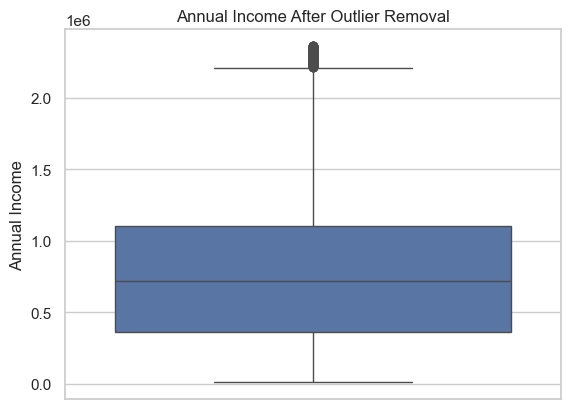

In [139]:
sns.boxplot(y=df['Annual Income'])
plt.title("Annual Income After Outlier Removal")
plt.show()

In [140]:

total_cars_sold = df.shape[0]

total_revenue = df['Price ($)'].sum()

average_car_price = df['Price ($)'].mean()

average_annual_income = df['Annual Income'].mean()

top_selling_company = df['Company'].value_counts().idxmax()

print("TOTAL CARS SOLD:", total_cars_sold)
print("TOTAL REVENUE:", round(total_revenue, 2))
print("AVERAGE CAR PRICE:", round(average_car_price, 2))
print("AVERAGE ANNUAL INCOME:", round(average_annual_income, 2))
print("TOP SELLING COMPANY:", top_selling_company)
highest_price = df['Price ($)'].max()
lowest_price = df['Price ($)'].min()

revenue_per_car = df['Price ($)'].mean()

unique_customers = df['Customer Name'].nunique()
total_dealers = df['Dealer_Name'].nunique()

most_popular_model = df['Model'].value_counts().idxmax()
most_popular_body = df['Body Style'].value_counts().idxmax()
most_used_transmission = df['Transmission'].value_counts().idxmax()

top_region_sales = df['Dealer_Region'].value_counts().idxmax()
top_region_revenue = df.groupby('Dealer_Region')['Price ($)'].sum().idxmax()

gender_ratio = df['Gender'].value_counts(normalize=True) * 100

print("HIGHEST PRICE:", highest_price)
print("LOWEST PRICE:", lowest_price)
print("REVENUE PER CAR:", round(revenue_per_car, 2))
print("UNIQUE CUSTOMERS:", unique_customers)
print("TOTAL DEALERS:", total_dealers)
print("MOST POPULAR MODEL:", most_popular_model)
print("MOST POPULAR BODY STYLE:", most_popular_body)
print("MOST USED TRANSMISSION:", most_used_transmission)
print("TOP REGION (SALES):", top_region_sales)
print("TOP REGION (REVENUE):", top_region_revenue)
print("GENDER RATIO (%):")
print(gender_ratio)


TOTAL CARS SOLD: 23090
TOTAL REVENUE: 647812493
AVERAGE CAR PRICE: 28055.98
AVERAGE ANNUAL INCOME: 749715.05
TOP SELLING COMPANY: Chevrolet
HIGHEST PRICE: 85800
LOWEST PRICE: 1200
REVENUE PER CAR: 28055.98
UNIQUE CUSTOMERS: 2970
TOTAL DEALERS: 28
MOST POPULAR MODEL: Diamante
MOST POPULAR BODY STYLE: SUV
MOST USED TRANSMISSION: Auto
TOP REGION (SALES): Austin
TOP REGION (REVENUE): Austin
GENDER RATIO (%):
Gender
Male      78.466869
Female    21.533131
Name: proportion, dtype: float64


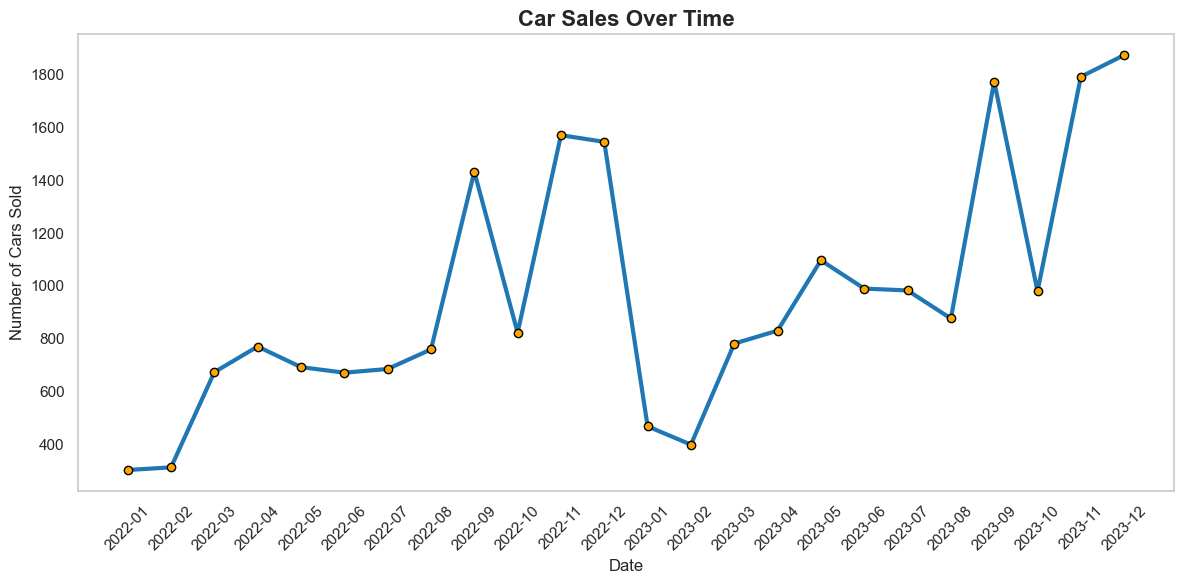

In [ ]:
sns.set(style="whitegrid")
sales_time = df.groupby(df['Date'].dt.to_period('M')).size()
plt.figure(figsize=(12,6))
plt.plot(sales_time.index.astype(str),sales_time.values,color='tab:blue',linewidth=3,marker='o',markersize=6,markerfacecolor='orange',markeredgecolor='black')
plt.title("Car Sales Over Time", fontsize=16, fontweight='bold')
plt.xlabel("Date", fontsize=12)
plt.ylabel("Number of Cars Sold", fontsize=12)
plt.xticks(rotation=45)
plt.grid(False)
plt.tight_layout()
plt.show()

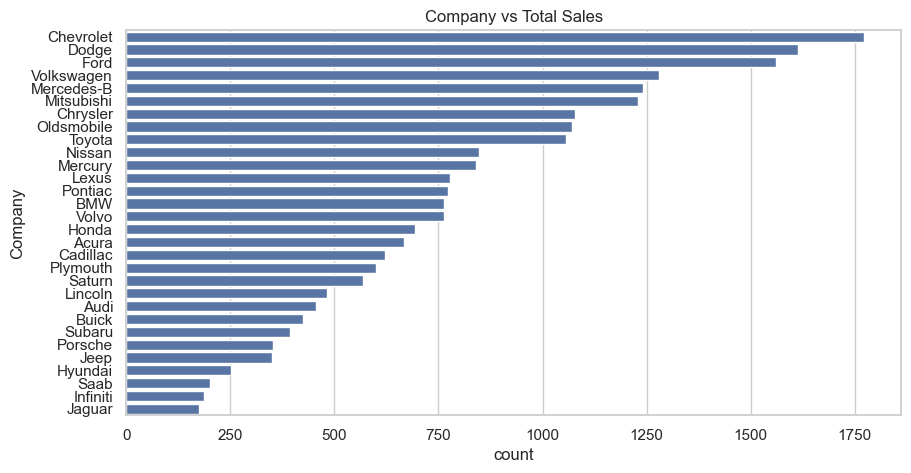

In [159]:
plt.figure(figsize=(10,5))
sns.countplot(y='Company', data=df, order=df['Company'].value_counts().index)
plt.title("Company vs Total Sales")
plt.show()




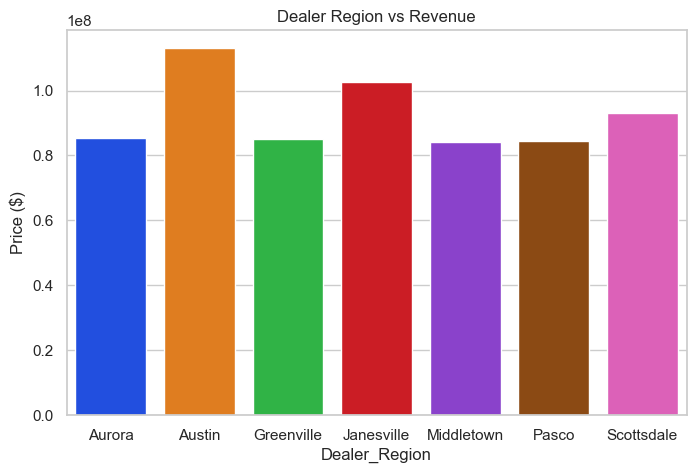

In [160]:
region_revenue = df.groupby('Dealer_Region')['Price ($)'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x='Dealer_Region', y='Price ($)', data=region_revenue,palette="bright",hue="Dealer_Region")
plt.title("Dealer Region vs Revenue")
plt.show()

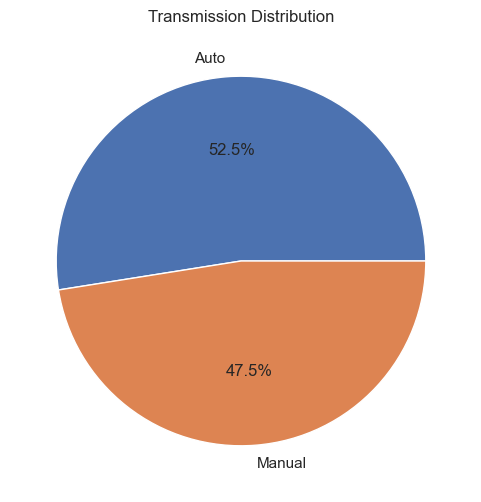

In [108]:
plt.figure(figsize=(6,6))
df['Transmission'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Transmission Distribution")
plt.ylabel("")
plt.show()


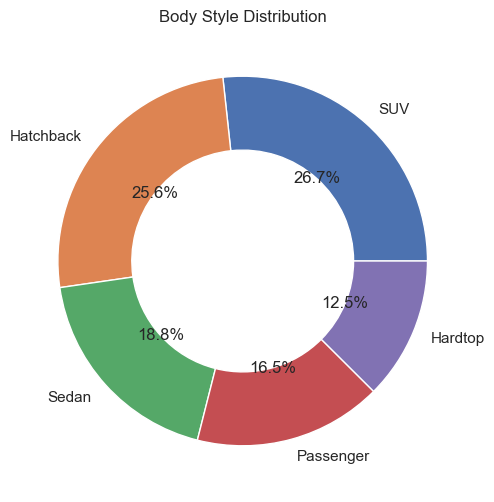

In [109]:
body_counts = df['Body Style'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(body_counts, labels=body_counts.index, autopct='%1.1f%%', wedgeprops=dict(width=0.4))
plt.title("Body Style Distribution")
plt.show()

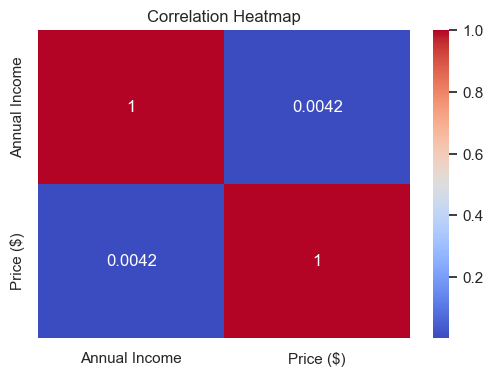

In [110]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Annual Income', 'Price ($)']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


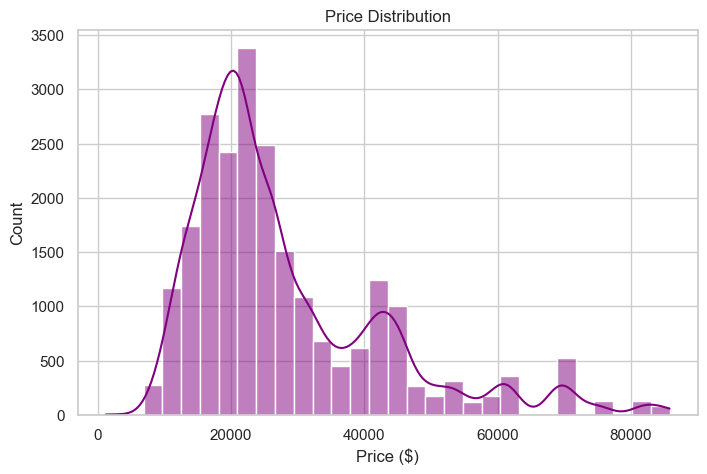

In [155]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price ($)'], bins=30, kde=True,color='purple')
plt.title("Price Distribution")
plt.show()

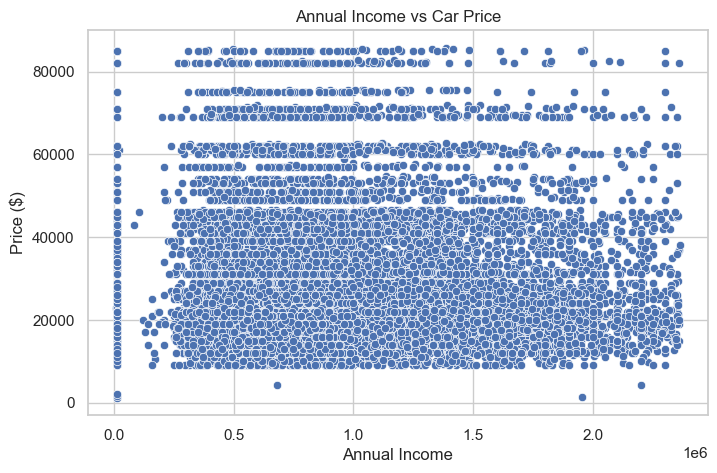

In [112]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Annual Income', y='Price ($)', data=df)
plt.title("Annual Income vs Car Price")
plt.show()

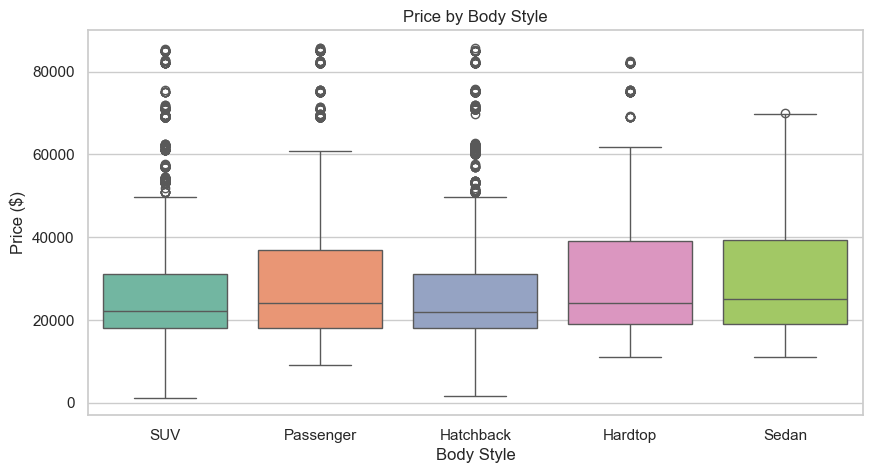

In [161]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Body Style', y='Price ($)', data=df,palette="Set2",hue="Body Style")
plt.title("Price by Body Style")
plt.show()

In [114]:
df.columns

Index(['Car_id', 'Date', 'Customer Name', 'Gender', 'Annual Income',
       'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color',
       'Price ($)', 'Dealer_No ', 'Body Style', 'Phone', 'Dealer_Region'],
      dtype='object')

In [ ]:

df = df.drop(columns=[
    'Date',
    'Car_id',
    'Customer Name',
    'Phone'
], errors='ignore')

df.head(), df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 23090 entries, 0 to 23905
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Gender         23090 non-null  object
 1   Annual Income  23090 non-null  int64 
 2   Dealer_Name    23090 non-null  object
 3   Company        23090 non-null  object
 4   Model          23090 non-null  object
 5   Engine         23090 non-null  object
 6   Transmission   23090 non-null  object
 7   Color          23090 non-null  object
 8   Price ($)      23090 non-null  int64 
 9   Dealer_No      23090 non-null  object
 10  Body Style     23090 non-null  object
 11  Dealer_Region  23090 non-null  object
dtypes: int64(2), object(10)
memory usage: 2.3+ MB


(  Gender  Annual Income                          Dealer_Name   Company  \
 0   Male          13500  Buddy Storbeck's Diesel Service Inc      Ford   
 1   Male        1480000                     C & M Motors Inc     Dodge   
 2   Male        1035000                          Capitol KIA  Cadillac   
 3   Male          13500               Chrysler of Tri-Cities    Toyota   
 4   Male        1465000                    Chrysler Plymouth     Acura   
 
         Model                     Engine Transmission       Color  Price ($)  \
 0  Expedition  DoubleÂ Overhead Camshaft         Auto       Black      26000   
 1     Durango  DoubleÂ Overhead Camshaft         Auto       Black      19000   
 2    Eldorado          Overhead Camshaft       Manual         Red      31500   
 3      Celica          Overhead Camshaft       Manual  Pale White      14000   
 4          TL  DoubleÂ Overhead Camshaft         Auto         Red      24500   
 
    Dealer_No  Body Style Dealer_Region  
 0  06457-3834    

In [116]:
categorical_cols = df.select_dtypes(include='object').columns
categorical_cols


Index(['Gender', 'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission',
       'Color', 'Dealer_No ', 'Body Style', 'Dealer_Region'],
      dtype='object')

In [117]:
df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

df_encoded.head(), df_encoded.shape


(   Annual Income  Price ($)  Gender_Male  Dealer_Name_C & M Motors Inc  \
 0          13500      26000         True                         False   
 1        1480000      19000         True                          True   
 2        1035000      31500         True                         False   
 3          13500      14000         True                         False   
 4        1465000      24500         True                         False   
 
    Dealer_Name_Capitol KIA  Dealer_Name_Chrysler Plymouth  \
 0                    False                          False   
 1                    False                          False   
 2                     True                          False   
 3                    False                          False   
 4                    False                           True   
 
    Dealer_Name_Chrysler of Tri-Cities  Dealer_Name_Classic Chevy  \
 0                               False                      False   
 1                               Fal

In [ ]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23090 entries, 0 to 23905
Columns: 232 entries, Annual Income to Dealer_Region_Scottsdale
dtypes: bool(230), int64(2)
memory usage: 5.6 MB


In [119]:
X = df_encoded.drop('Price ($)', axis=1)
y = df_encoded['Price ($)']

In [120]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [121]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((18472, 231), (4618, 231), (18472,), (4618,))

In [122]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [123]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)


In [124]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2
lr_mae, lr_rmse, lr_r2 = evaluate_model(y_test, y_pred_lr)
rf_mae, rf_rmse, rf_r2 = evaluate_model(y_test, y_pred_rf)
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2 Score": [lr_r2, rf_r2]
})

results


,Model,MAE,RMSE,R2 Score
0,Linear Regression,9441.928076,12701.207406,0.241089
1,Random Forest,4342.783734,8683.155006,0.645304


In [ ]:

while True:
    choice = input("Do you want to predict car price? (yes/no): ").strip().lower()

    if choice == "no":
        print("Thank you! Program exited.")
        break

    elif choice == "yes":
        print("\nEnter car details below:\n")

        gender = input("Gender (Male/Female): ")
        annual_income = float(input("Annual Income: "))
        dealer_name = input("Dealer Name: ")
        company = input("Company: ")
        model = input("Model: ")
        engine = input("Engine Type: ")
        transmission = input("Transmission (Auto/Manual): ")
        color = input("Color: ")
        dealer_no = input("Dealer No: ")
        body_style = input("Body Style: ")
        dealer_region = input("Dealer Region: ")
        year = int(input("Year: "))
        month = int(input("Month (1-12): "))

        
        user_input = {
            "Gender": gender,
            "Annual Income": annual_income,
            "Dealer_Name": dealer_name,
            "Company": company,
            "Model": model,
            "Engine": engine,
            "Transmission": transmission,
            "Color": color,
            "Dealer_No": dealer_no,
            "Body Style": body_style,
            "Dealer_Region": dealer_region,
            "Year": year,
            "Month": month
        }

        user_df = pd.DataFrame([user_input])
        user_encoded = pd.get_dummies(user_df)
        user_encoded = user_encoded.reindex(
            columns=X_train.columns,
            fill_value=0
        )
        predicted_price = rf.predict(user_encoded)

        print("\nPredicted Car Price ($):", round(predicted_price[0], 2))

    else:
        print("Invalid input! Please type yes or no.\n")


Enter car details below:


Predicted Car Price ($): 21970.14
Thank you! Program exited.
